# DMW Methylation × RNA Expression Heatmap

Adapted from `260409_customize_corr_copy.ipynb` (gene-level) for **DMW MCDS** files.

**Pipeline:**
1. Load both DMW MCDS files (concat along `cell`)
2. Load RNA counts + cell cluster metadata
3. Compute logit-adjusted methylation residuals per cluster (per DMW)
4. Map each DMW to overlapping gene(s) via gene-body overlap
5. WLS-correlate DMW methylation residual vs RNA expression across clusters
6. Plot side-by-side heatmap of top anti-correlated DMW–gene pairs

**Before running, edit paths in Cell 2** and verify the sanity-check outputs in Cell 3.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import xarray as xr
from scipy.stats import zscore
from scipy.special import logit, expit
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
from matplotlib.colors import LinearSegmentedColormap
import scipy.cluster.hierarchy as hc
import scipy.spatial as sp
from ALLCools.mcds import MCDS

In [2]:
# ---- EDIT PATHS HERE ----
mcds_paths = [
    "/ceph/MethDev/pbio/andy/JW/section_4/All_mcds_dmw3_0.mcds",
    "/ceph/MethDev/pbio/andy/JW/section_4/All_mcds_dmw3_1.mcds",
]
rna_path   = "../../hazel/count_Arab13_with_TEs.csv"
meta_path  = "../../hazel/merged_cluster_assignments.csv"
genes_bed  = "/ceph/MethDev/pbio/andy/JW/section_4/genes.fixed.bed"
fig_outdir = "./figures/heatmaps"

# Methylation context to analyze (verify in next cell)
MC_TYPE = "CGN"

# Coverage filter for DMWs (sum across clusters)
MIN_COV = 50

# How many top anti-correlated pairs to plot
TOP_N   = 300
# -------------------------

# Open both MCDS files together; ALLCools concatenates them on cell automatically
mcds = MCDS.open(mcds_paths=mcds_paths, var_dim="dmw")

rna  = pd.read_csv(rna_path).T
meta = pd.read_csv(meta_path).set_index("cell_id")

print(f"MCDS dims: {dict(mcds.dims)}")
print(f"RNA shape: {rna.shape}")
print(f"Meta shape: {meta.shape}")

MCDS dims: {'cell': 6071, 'count_type': 2, 'dmw': 22467, 'mc_type': 4}
RNA shape: (6071, 64507)
Meta shape: (5908, 1)


In [3]:
# ---- Sanity checks: run these BEFORE the heavy computation ----
print("Available mc_types:    ", mcds.coords["mc_type"].values.tolist())
print("Available count_types: ", mcds.coords["count_type"].values.tolist())
if "strand_type" in mcds.coords:
    print("Available strand_types:", mcds.coords["strand_type"].values.tolist())

print(f"\nUsing MC_TYPE = '{MC_TYPE}' — adjust above if wrong context name.")

# Cluster column
print(f"\nMeta columns: {meta.columns.tolist()}")
print(f"Unique clusters in meta: {sorted(meta['merged_cluster'].unique())}")

Available mc_types:     ['CHH', 'CHG', 'CHN', 'CGN']
Available count_types:  ['mc', 'cov']
Available strand_types: both

Using MC_TYPE = 'CGN' — adjust above if wrong context name.

Meta columns: ['merged_cluster']
Unique clusters in meta: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


In [4]:
# Build a DMW coordinate table for later overlap with genes
dmw_bed = pd.DataFrame({
    "chrom":  mcds["dmw_chrom"].values,
    "start":  mcds["dmw_start"].values.astype(int),
    "end":    mcds["dmw_end"].values.astype(int),
    "dmw_id": mcds.get_index("dmw").values,
})
print(dmw_bed.head())
print(f"\nTotal DMWs:           {len(dmw_bed)}")
print(f"DMW chrom values:     {sorted(dmw_bed['chrom'].unique())}")
print(f"DMW length stats (bp): min={dmw_bed.eval('end-start').min()}, "
      f"median={int(dmw_bed.eval('end-start').median())}, "
      f"max={dmw_bed.eval('end-start').max()}")

   chrom  start    end dmw_id
0      1  23901  25400  dmw=1
1      1  25601  27200  dmw=2
2      1  27401  30200  dmw=3
3      1  30401  30900  dmw=4
4      1  31601  32000  dmw=5

Total DMWs:           22467
DMW chrom values:     [1, 2, 3, 4, 5]
DMW length stats (bp): min=199, median=399, max=6099


In [5]:
# RNA per-cluster matrix (log1p CPM, mean per cluster)
common_cells = rna.index.intersection(meta.index)
print(f"Cells with both RNA and meta: {len(common_cells)}")

rna_aligned = rna.loc[common_cells]
cell_totals = rna_aligned.sum(axis=1)
rna_cpm     = rna_aligned.div(cell_totals, axis=0) * 1e6
rna_log1p   = np.log1p(rna_cpm)

rna_log1p["cluster"] = meta.loc[common_cells, "merged_cluster"]
cluster_rna_matrix   = rna_log1p.groupby("cluster").mean().T   # genes × clusters

print(f"RNA cluster matrix: {cluster_rna_matrix.shape}  (genes × clusters)")
print(f"Cluster columns:    {cluster_rna_matrix.columns.tolist()}")

Cells with both RNA and meta: 5908
RNA cluster matrix: (64507, 17)  (genes × clusters)
Cluster columns:    [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


In [6]:
# DMW methylation residuals per cluster (logit-adjusted)
mCG_mc  = mcds.sel(mc_type=MC_TYPE, count_type="mc").dmw_da.to_pandas()
mCG_cov = mcds.sel(mc_type=MC_TYPE, count_type="cov").dmw_da.to_pandas()

# Restrict to cells with cluster assignment
keep = mCG_mc.index.intersection(meta.index)
mCG_mc, mCG_cov = mCG_mc.loc[keep], mCG_cov.loc[keep]
mCG_mc["cluster"]  = meta.loc[keep, "merged_cluster"]
mCG_cov["cluster"] = meta.loc[keep, "merged_cluster"]

cluster_c = mCG_mc.groupby("cluster").sum().T   # dmw × clusters
cluster_m = mCG_cov.groupby("cluster").sum().T

# --- Logit-adjusted residuals (same math as the gene-level original) ---
global_c = cluster_c.sum(axis=0)
global_m = cluster_m.sum(axis=0)
global_p = global_c / global_m
d        = logit(np.clip(global_p, 1e-6, 1 - 1e-6))
deltas   = d - np.average(d, weights=global_m)

dmw_c = cluster_c.sum(axis=1)
dmw_m = cluster_m.sum(axis=1)

valid = dmw_m >= MIN_COV
cluster_c, cluster_m = cluster_c[valid], cluster_m[valid]
dmw_c, dmw_m         = dmw_c[valid],     dmw_m[valid]
print(f"DMWs passing coverage filter (>= {MIN_COV}): {valid.sum()} / {len(valid)}")

pbar = np.clip(dmw_c / dmw_m, 1e-6, 1 - 1e-6)
expected_logit = logit(pbar).values[:, None] + deltas.values[None, :]
p0_df = pd.DataFrame(expit(expected_logit),
                     index=cluster_c.index, columns=cluster_c.columns)

obs_p = (cluster_c / cluster_m.replace(0, np.nan)).fillna(0)
adj_meth_matrix = obs_p - p0_df

# Keep DMWs with meaningful methylation in at least one cluster
highly_meth = obs_p[obs_p.apply(lambda x: (x >= 0.1).any(), axis=1)].index
filtered_meth_df = adj_meth_matrix.loc[highly_meth]
print(f"DMWs after methylation filter: {len(filtered_meth_df)}")

DMWs passing coverage filter (>= 50): 22467 / 22467
DMWs after methylation filter: 22397


In [7]:
# DMW → gene mapping by gene-body overlap
import bioframe as bf

# REBUILD dmw_bed fresh from MCDS so re-running this cell is safe
dmw_bed = pd.DataFrame({
    "chrom":  mcds["dmw_chrom"].values,
    "start":  mcds["dmw_start"].values.astype(int),
    "end":    mcds["dmw_end"].values.astype(int),
    "dmw_id": mcds.get_index("dmw").values,
})

# Load genes
genes = pd.read_csv(
    genes_bed, sep="\t", header=None,
    names=["chrom", "start", "end", "gene", "score", "strand"],
    usecols=[0, 1, 2, 3],
)
print(f"Loaded {len(genes)} gene records")
print(f"Gene chrom values BEFORE: {sorted(genes['chrom'].unique())}")
print(f"DMW chrom values BEFORE:  {sorted(dmw_bed['chrom'].unique())}")

# Harmonize: add lowercase 'chr' prefix to DMW chroms (which are bare integers)
dmw_bed["chrom"] = "chr" + dmw_bed["chrom"].astype(str)

print(f"\nDMW chrom values AFTER:   {sorted(dmw_bed['chrom'].unique())}")

assert set(dmw_bed["chrom"]) & set(genes["chrom"]), \
    "No shared chromosome names — harmonize naming above before continuing."

# Inner overlap
overlaps = bf.overlap(
    dmw_bed, genes,
    cols1=("chrom", "start", "end"),
    cols2=("chrom", "start", "end"),
    how="inner",
    suffixes=("_dmw", "_gene"),
)
print("Overlap columns:", overlaps.columns.tolist())

# Find the dmw_id and gene columns regardless of suffix
dmw_col  = next(c for c in overlaps.columns if c.startswith("dmw_id"))
gene_col = next(c for c in overlaps.columns if c == "gene" or c.startswith("gene_"))

dmw_to_gene = (
    overlaps[[dmw_col, gene_col]]
    .rename(columns={dmw_col: "dmw_id", gene_col: "gene"})
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f"\nDMW–gene overlap pairs: {len(dmw_to_gene)}")
print(f"Unique DMWs with a gene:    {dmw_to_gene['dmw_id'].nunique()}")
print(f"Unique genes hit by a DMW:  {dmw_to_gene['gene'].nunique()}")
multi = dmw_to_gene.groupby("dmw_id").size()
print(f"DMWs overlapping >1 gene:   {(multi > 1).sum()} (max {multi.max()})")

Loaded 33326 gene records
Gene chrom values BEFORE: ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chrC', 'chrM']
DMW chrom values BEFORE:  [1, 2, 3, 4, 5]

DMW chrom values AFTER:   ['chr1', 'chr2', 'chr3', 'chr4', 'chr5']
Overlap columns: ['chrom_dmw', 'start_dmw', 'end_dmw', 'dmw_id_dmw', 'chrom_gene', 'start_gene', 'end_gene', 'gene_gene']

DMW–gene overlap pairs: 20622
Unique DMWs with a gene:    19677
Unique genes hit by a DMW:  11788
DMWs overlapping >1 gene:   897 (max 7)


In [8]:
# WLS correlation per (DMW, gene) pair across clusters
results = []
skipped = {"missing": 0, "novar": 0, "fit_error": 0}

# Pre-index for speed
meth_idx = filtered_meth_df.index
rna_idx  = cluster_rna_matrix.index

for dmw_id, gene in dmw_to_gene.itertuples(index=False):
    if dmw_id not in meth_idx or gene not in rna_idx:
        skipped["missing"] += 1
        continue

    rna_vals  = cluster_rna_matrix.loc[gene].values
    meth_vals = filtered_meth_df.loc[dmw_id].values
    weights   = cluster_m.loc[dmw_id].values

    if np.std(rna_vals) == 0 or np.std(meth_vals) == 0:
        skipped["novar"] += 1
        continue

    X = sm.add_constant(zscore(meth_vals))
    try:
        wls = sm.WLS(zscore(rna_vals), X, weights=weights).fit()
        results.append((dmw_id, gene, wls.params[1], wls.pvalues[1]))
    except Exception:
        skipped["fit_error"] += 1
        continue

stats_df = pd.DataFrame(results, columns=["dmw_id", "gene", "rho", "p_value"])
stats_df["fdr"] = multipletests(stats_df["p_value"], method="fdr_bh")[1]

print(f"Tested pairs: {len(stats_df)}  | skipped: {skipped}")
print(f"\nTop 20 most negatively correlated DMW–gene pairs:")
print(stats_df.sort_values("rho").head(20))

Tested pairs: 19958  | skipped: {'missing': 54, 'novar': 610, 'fit_error': 0}

Top 20 most negatively correlated DMW–gene pairs:
          dmw_id       gene       rho       p_value       fdr
19613  dmw=16844  AT4G35090 -1.707847  7.931681e-04  0.074670
3416    dmw=3696  AT1G54560 -1.472718  1.510010e-02  0.301953
11799  dmw=10982  AT3G20720 -1.464037  2.329575e-02  0.349907
4398    dmw=4759  AT1G68010 -1.430496  2.946449e-04  0.040837
17589  dmw=14735  AT4G10120 -1.401177  2.078899e-03  0.126489
18357  dmw=15567  AT4G19180 -1.399646  4.389971e-03  0.184842
12782  dmw=12546  AT3G47910 -1.381458  4.769164e-03  0.191759
11891  dmw=11073  AT3G21670 -1.327715  1.615086e-06  0.001113
77      dmw=4806  AT1G68780 -1.320954  1.590236e-04  0.028087
492      dmw=408  AT1G06460 -1.303893  2.370525e-03  0.133270
13183  dmw=12968  AT3G53460 -1.298879  6.332682e-04  0.064576
17304  dmw=14094  AT4G04330 -1.262589  1.263225e-04  0.024717
2428    dmw=2422  AT1G32060 -1.233320  3.569301e-03  0.165342
127

Plotting top 300 DMW–gene pairs (most negative WLS rho).
Saved: ./figures/heatmaps/dmw_rna_wls_top300_clustered_heatmap.png


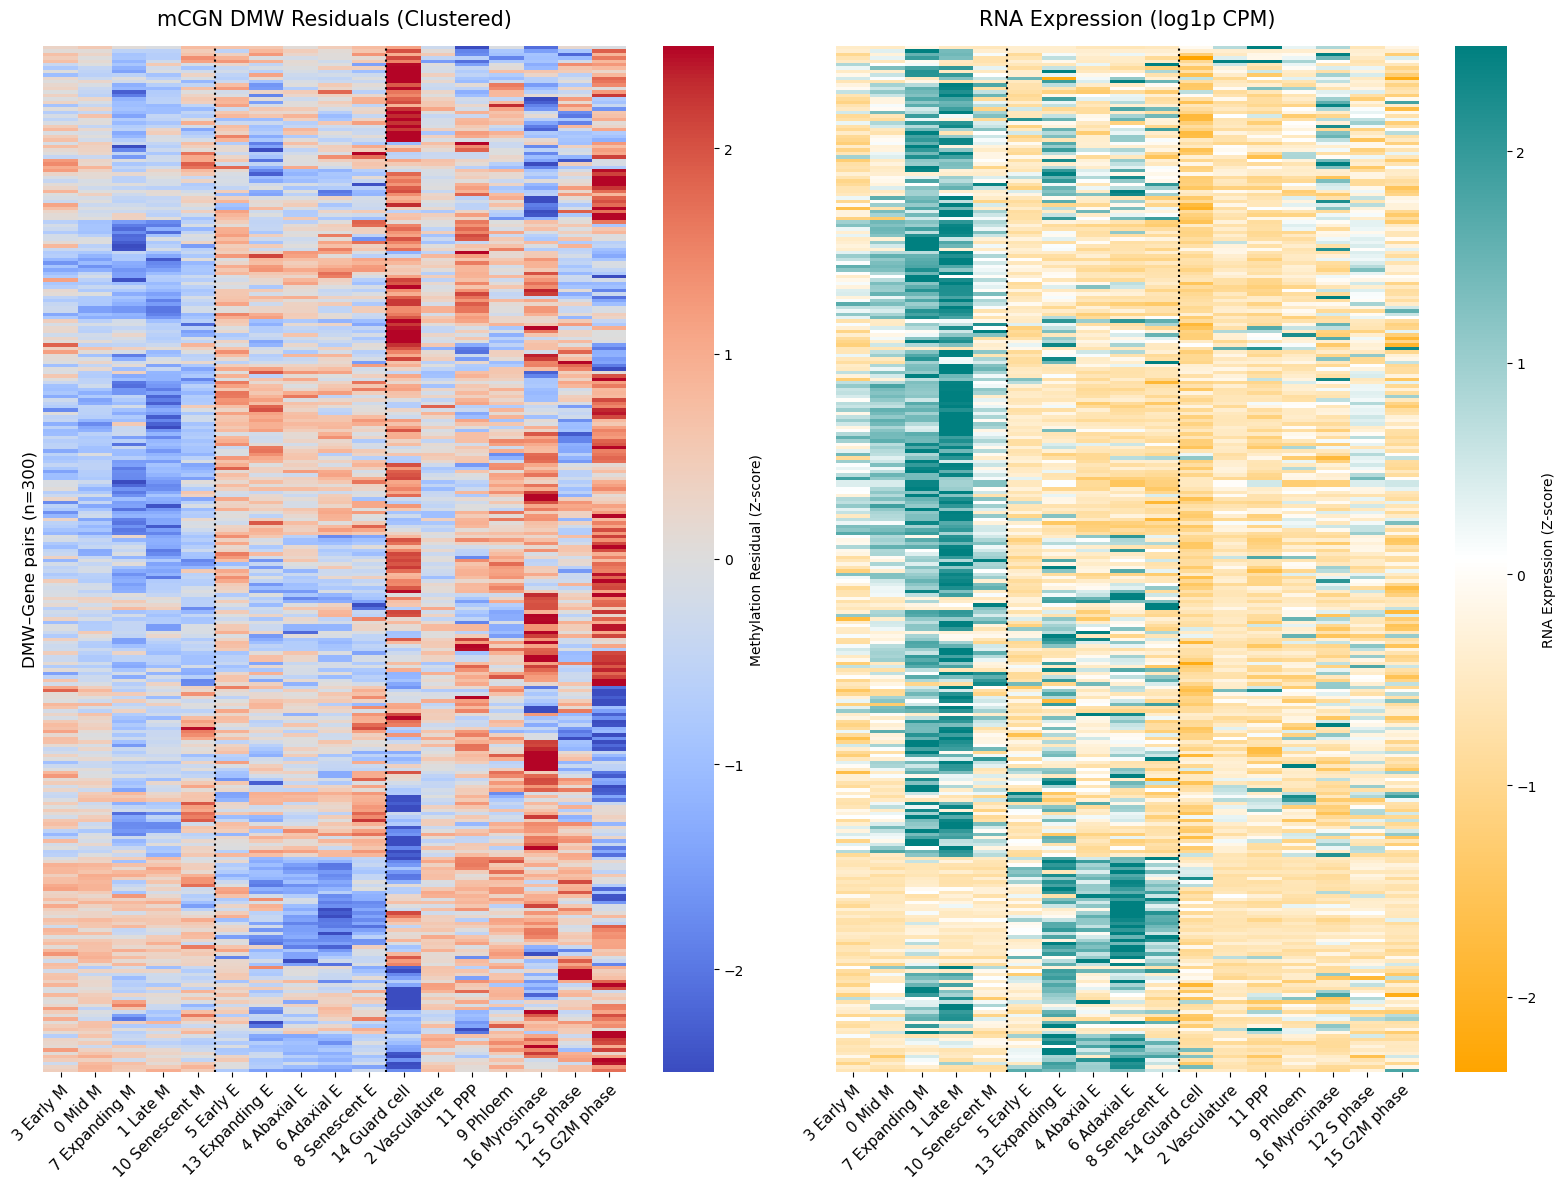

In [9]:
# Heatmap: top anti-correlated DMW–gene pairs
import os
os.makedirs(fig_outdir, exist_ok=True)

# --- Cluster naming (edit to match your dataset's biology) ---
cluster_mapping = {
    3: '3 Early M', 0: '0 Mid M', 7: '7 Expanding M', 1: '1 Late M', 10: '10 Senescent M',
    5: '5 Early E', 4: '4 Abaxial E', 6: '6 Adaxial E', 13: '13 Expanding E', 8: '8 Senescent E',
    14: '14 Guard cell', 2: '2 Vasculature', 11: '11 PPP', 9: '9 Phloem',
    16: '16 Myrosinase', 12: '12 S phase', 15: '15 G2M phase'
}
cluster_mapping.update({str(k): v for k, v in cluster_mapping.items()})

cluster_order = [
    '3 Early M', '0 Mid M', '7 Expanding M', '1 Late M', '10 Senescent M',
    '5 Early E', '13 Expanding E', '4 Abaxial E', '6 Adaxial E', '8 Senescent E',
    '14 Guard cell', '2 Vasculature', '11 PPP', '9 Phloem',
    '16 Myrosinase', '12 S phase', '15 G2M phase'
]
clusters_to_drop = []   # e.g. ["14 Guard cell", "15 G2M phase"]

# --- Pick top-N most negatively correlated pairs ---
top_pairs = stats_df.sort_values("rho").head(TOP_N).reset_index(drop=True)
print(f"Plotting top {len(top_pairs)} DMW–gene pairs (most negative WLS rho).")

# Matched matrices, one row per pair
meth_rows = filtered_meth_df.loc[top_pairs["dmw_id"].values].copy()
rna_rows  = cluster_rna_matrix.loc[top_pairs["gene"].values].copy()
row_labels = [f"{d} | {g}" for d, g in zip(top_pairs["dmw_id"], top_pairs["gene"])]
meth_rows.index = row_labels
rna_rows.index  = row_labels

def prepare_zscore(df):
    z = df.apply(zscore, axis=1)
    return z.clip(lower=-2.5, upper=2.5)

vis_meth_z = prepare_zscore(meth_rows).rename(columns=cluster_mapping)
vis_rna_z  = prepare_zscore(rna_rows).rename(columns=cluster_mapping)

valid_order = [c for c in cluster_order
               if c in vis_meth_z.columns and c not in clusters_to_drop]
vis_meth_z = vis_meth_z[valid_order]
vis_rna_z  = vis_rna_z[valid_order]

# Hierarchical clustering on rows (using methylation) — apply same order to RNA
row_linkage = hc.linkage(sp.distance.pdist(vis_meth_z.values), method="ward")
row_order   = hc.leaves_list(row_linkage)
vis_meth_clustered = vis_meth_z.iloc[row_order]
vis_rna_clustered  = vis_rna_z.iloc[row_order]

rna_cmap = LinearSegmentedColormap.from_list(
    "Orange_White_Teal", ["orange", "white", "teal"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 12),
                               gridspec_kw={"width_ratios": [1, 1]})

sns.heatmap(vis_meth_clustered, cmap="coolwarm", center=0, ax=ax1,
            cbar_kws={"label": "Methylation Residual (Z-score)"},
            yticklabels=False)
ax1.set_title(f"m{MC_TYPE} DMW Residuals (Clustered)", fontsize=15, pad=15)
ax1.set_ylabel(f"DMW–Gene pairs (n={len(top_pairs)})", fontsize=12)
ax1.set_xlabel("")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right",
                    rotation_mode="anchor")
ax1.tick_params(axis="x", labelsize=11)

sns.heatmap(vis_rna_clustered, cmap=rna_cmap, ax=ax2,
            cbar_kws={"label": "RNA Expression (Z-score)"},
            yticklabels=False)
ax2.set_title("RNA Expression (log1p CPM)", fontsize=15, pad=15)
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right",
                    rotation_mode="anchor")
ax2.tick_params(axis="x", labelsize=11)

# Optional: vertical dividers between developmental stages
divider_positions = [
    i + 1 for i, col in enumerate(valid_order)
    if "Senescent M" in col or "Senescent E" in col
]
for ax in [ax1, ax2]:
    for pos in divider_positions:
        ax.axvline(pos, color="black", lw=1.5, linestyle=":")

plt.tight_layout()
out_path = f"{fig_outdir}/dmw_rna_wls_top{TOP_N}_clustered_heatmap.png"
plt.savefig(out_path, format="png", dpi=300, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

In [10]:
# Optional: save the full stats table for downstream analysis
stats_df.sort_values("rho").to_csv("dmw_gene_wls_stats.tsv", sep="\t", index=False)
print(f"Saved {len(stats_df)} pairs to dmw_gene_wls_stats.tsv")

# Quick summary of FDR-significant negative pairs
sig_neg = stats_df[(stats_df["fdr"] < 0.05) & (stats_df["rho"] < 0)]
print(f"\nFDR<0.05 negative pairs: {len(sig_neg)}")
print(f"FDR<0.05 positive pairs: {len(stats_df[(stats_df['fdr'] < 0.05) & (stats_df['rho'] > 0)])}")

Saved 19958 pairs to dmw_gene_wls_stats.tsv

FDR<0.05 negative pairs: 128
FDR<0.05 positive pairs: 27


In [13]:
# ---- Thorough inspection of a single gene ----
GENE = "AT5G53210"

# === 1. Basic gene info from annotation ===
gene_info = genes[genes["gene"] == GENE]
if gene_info.empty:
    print(f"⚠️  {GENE} not found in gene annotation")
else:
    print(f"=== {GENE} location ===")
    print(gene_info.to_string(index=False))
    g_chrom = gene_info.iloc[0]["chrom"]
    g_start = int(gene_info.iloc[0]["start"])
    g_end   = int(gene_info.iloc[0]["end"])
    print(f"Length: {g_end - g_start} bp")

=== AT5G53210 location ===
chrom    start      end      gene
 chr5 21586218 21589255 AT5G53210
Length: 3037 bp


In [14]:
# === 2. DMWs overlapping this gene ===
overlapping_dmws = dmw_to_gene[dmw_to_gene["gene"] == GENE]["dmw_id"].tolist()
print(f"\n=== DMWs overlapping {GENE}: {len(overlapping_dmws)} ===")

if overlapping_dmws:
    # Show their genomic positions
    dmw_info = dmw_bed[dmw_bed["dmw_id"].isin(overlapping_dmws)].copy()
    dmw_info["length"] = dmw_info["end"] - dmw_info["start"]
    print(dmw_info.to_string(index=False))
else:
    print("No overlapping DMWs found for this gene.")


=== DMWs overlapping AT5G53210: 1 ===
chrom    start      end    dmw_id  length
 chr5 21588001 21588200 dmw=21488     199


In [15]:
# === 3. WLS stats for each DMW–gene pair ===
print(f"\n=== WLS results for {GENE} ===")
gene_stats = stats_df[stats_df["gene"] == GENE].sort_values("rho")
if gene_stats.empty:
    print(f"{GENE} not in stats_df (may have been filtered out by coverage/methylation thresholds)")
else:
    print(gene_stats.to_string(index=False))
    # Rank within all pairs
    print(f"\nGene's best rho rank: "
          f"{stats_df.sort_values('rho').reset_index(drop=True).query('gene == @GENE').index.tolist()} "
          f"out of {len(stats_df)} total pairs")


=== WLS results for AT5G53210 ===
   dmw_id      gene       rho  p_value      fdr
dmw=21488 AT5G53210 -0.098543 0.582898 0.875278

Gene's best rho rank: [6416] out of 19958 total pairs


In [16]:
# === 4. RNA expression across clusters ===
print(f"\n=== RNA expression of {GENE} (log1p CPM, mean per cluster) ===")
if GENE in cluster_rna_matrix.index:
    rna_profile = cluster_rna_matrix.loc[GENE]
    rna_named = rna_profile.rename(index=cluster_mapping)
    print(rna_named.sort_values(ascending=False).to_string())
    print(f"\nmean: {rna_profile.mean():.3f}, max: {rna_profile.max():.3f}, "
          f"min: {rna_profile.min():.3f}, std: {rna_profile.std():.3f}")
else:
    print(f"{GENE} not in RNA matrix")


=== RNA expression of AT5G53210 (log1p CPM, mean per cluster) ===
cluster
5 Early E         1.125170
15 G2M phase      0.970329
14 Guard cell     0.349142
12 S phase        0.302605
3 Early M         0.108535
4 Abaxial E       0.088971
13 Expanding E    0.064565
16 Myrosinase     0.059959
2 Vasculature     0.053798
0 Mid M           0.053339
6 Adaxial E       0.042048
1 Late M          0.036695
7 Expanding M     0.035229
8 Senescent E     0.033485
11 PPP            0.029347
9 Phloem          0.025254
10 Senescent M    0.011153

mean: 0.199, max: 1.125, min: 0.011, std: 0.334


In [17]:
# === 5. Methylation residual profile per overlapping DMW ===
print(f"\n=== Methylation residuals (logit-adjusted) per DMW ===")
for dmw_id in overlapping_dmws:
    if dmw_id in filtered_meth_df.index:
        meth_profile = filtered_meth_df.loc[dmw_id].rename(index=cluster_mapping)
        print(f"\n--- {dmw_id} ---")
        print(meth_profile.sort_values().to_string())
    else:
        print(f"\n--- {dmw_id}: filtered out (low coverage or low methylation) ---")


=== Methylation residuals (logit-adjusted) per DMW ===

--- dmw=21488 ---
cluster
14 Guard cell    -0.221103
6 Adaxial E      -0.190705
4 Abaxial E      -0.110531
15 G2M phase     -0.082417
13 Expanding E   -0.071093
16 Myrosinase    -0.043284
12 S phase       -0.033758
5 Early E        -0.031021
7 Expanding M    -0.024098
1 Late M         -0.011389
10 Senescent M   -0.002835
3 Early M         0.007753
9 Phloem          0.014016
11 PPP            0.015587
8 Senescent E     0.019215
0 Mid M           0.047235
2 Vasculature     0.109835


In [18]:
# === 6. Raw methylation rate (mc/cov) per DMW ===
print(f"\n=== Raw methylation rate (observed mc/cov) per DMW ===")
for dmw_id in overlapping_dmws:
    if dmw_id in cluster_c.index:
        c_vals = cluster_c.loc[dmw_id]
        m_vals = cluster_m.loc[dmw_id]
        rate = (c_vals / m_vals.replace(0, np.nan)).rename(index=cluster_mapping)
        cov  = m_vals.rename(index=cluster_mapping)
        df = pd.DataFrame({"mC_rate": rate, "coverage": cov.astype(int)})
        print(f"\n--- {dmw_id} ---")
        print(df.sort_values("mC_rate", ascending=False).to_string())


=== Raw methylation rate (observed mc/cov) per DMW ===

--- dmw=21488 ---
                 mC_rate  coverage
cluster                           
2 Vasculature   0.384117       617
11 PPP          0.289308       159
0 Mid M         0.283302      2132
7 Expanding M   0.282759       435
1 Late M        0.261589      1208
3 Early M       0.249370       397
5 Early E       0.240664       241
9 Phloem        0.223301       103
15 G2M phase    0.217391        23
12 S phase      0.216561       157
8 Senescent E   0.189922       258
13 Expanding E  0.187500       128
16 Myrosinase   0.181818        11
4 Abaxial E     0.162349       579
10 Senescent M  0.162011       179
14 Guard cell   0.096774        62
6 Adaxial E     0.056995       386


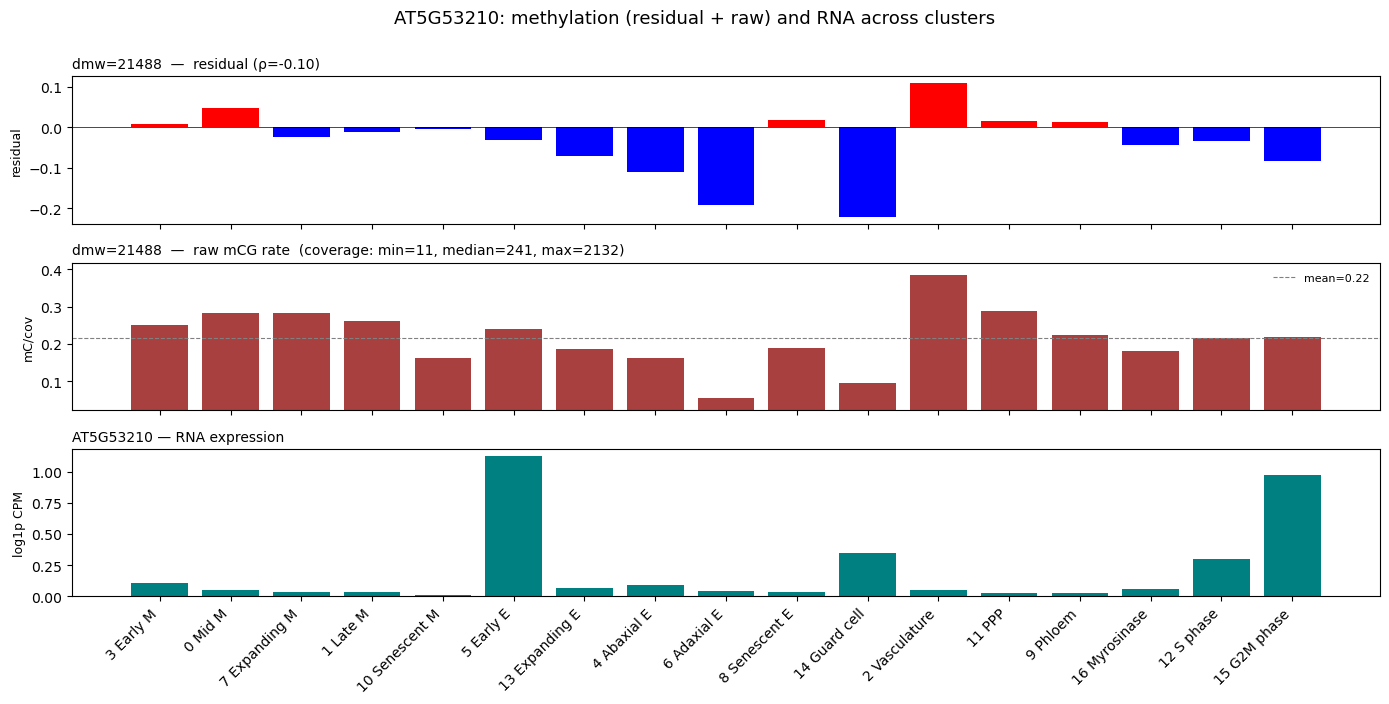

In [21]:
# === 7. Side-by-side visual: methylation residual + raw rate + expression ===
import matplotlib.pyplot as plt

if not gene_stats.empty and GENE in cluster_rna_matrix.index:
    valid_clusters = [c for c in cluster_order
                      if c in cluster_rna_matrix.rename(columns=cluster_mapping).columns]

    rna_vec = cluster_rna_matrix.loc[GENE].rename(index=cluster_mapping)[valid_clusters]

    # Only plot DMWs that have both residual AND raw rate data available
    plot_dmws = [d for d in overlapping_dmws
                 if d in filtered_meth_df.index and d in cluster_c.index]
    n_dmws = len(plot_dmws)

    if n_dmws == 0:
        print("No DMWs with both residual and raw-rate data; nothing to plot.")
    else:
        # Two methylation rows per DMW + one RNA row at the bottom
        n_rows = 2 * n_dmws + 1
        fig, axes = plt.subplots(n_rows, 1,
                                 figsize=(14, 2.0 * n_rows + 1),
                                 sharex=True)
        if n_rows == 1:
            axes = [axes]

        plot_idx = 0
        for dmw_id in plot_dmws:
            # --- Row A: methylation residual (logit-adjusted) ---
            meth_resid = (filtered_meth_df.loc[dmw_id]
                          .rename(index=cluster_mapping)[valid_clusters])
            rho_val = gene_stats[gene_stats["dmw_id"] == dmw_id]["rho"].values
            rho_str = f"ρ={rho_val[0]:.2f}" if len(rho_val) else "n/a"

            axes[plot_idx].bar(range(len(meth_resid)), meth_resid.values,
                               color=["red" if v > 0 else "blue"
                                      for v in meth_resid.values])
            axes[plot_idx].axhline(0, color="black", lw=0.5)
            axes[plot_idx].set_ylabel("residual", fontsize=9)
            axes[plot_idx].set_title(f"{dmw_id}  —  residual ({rho_str})",
                                     fontsize=10, loc="left")
            plot_idx += 1

            # --- Row B: raw methylation rate (mc/cov) ---
            c_vals = cluster_c.loc[dmw_id]
            m_vals = cluster_m.loc[dmw_id]
            raw_rate = (c_vals / m_vals.replace(0, np.nan)).rename(index=cluster_mapping)[valid_clusters]
            cov_vals = m_vals.rename(index=cluster_mapping)[valid_clusters]

            axes[plot_idx].bar(range(len(raw_rate)), raw_rate.values,
                               color="darkred", alpha=0.75)
            axes[plot_idx].set_ylabel("mC/cov", fontsize=9)
            
            # Auto-scale: tight to the data with 5% padding, clipped to [0, 1]
            rmin, rmax = raw_rate.min(), raw_rate.max()
            pad = max(0.02, (rmax - rmin) * 0.1)
            axes[plot_idx].set_ylim(max(0, rmin - pad), min(1, rmax + pad))
            
            axes[plot_idx].axhline(raw_rate.mean(), color="grey",
                                   lw=0.8, linestyle="--",
                                   label=f"mean={raw_rate.mean():.2f}")
            axes[plot_idx].legend(loc="upper right", fontsize=8, frameon=False)
            axes[plot_idx].set_title(
                f"{dmw_id}  —  raw mCG rate  "
                f"(coverage: min={int(cov_vals.min())}, "
                f"median={int(cov_vals.median())}, "
                f"max={int(cov_vals.max())})",
                fontsize=10, loc="left")
            plot_idx += 1

        # --- Final row: RNA expression ---
        axes[-1].bar(range(len(rna_vec)), rna_vec.values, color="teal")
        axes[-1].set_ylabel("log1p CPM", fontsize=9)
        axes[-1].set_title(f"{GENE} — RNA expression",
                           fontsize=10, loc="left")
        axes[-1].set_xticks(range(len(rna_vec)))
        axes[-1].set_xticklabels(rna_vec.index, rotation=45, ha="right")

        plt.suptitle(
            f"{GENE}: methylation (residual + raw) and RNA across clusters",
            fontsize=13, y=1.00)
        plt.subplots_adjust(hspace=0.55)
        plt.tight_layout()
        plt.savefig(f"{fig_outdir}/{GENE}_inspection.png",
                    dpi=200, bbox_inches="tight")
        plt.show()